In [1]:
import numpy as np
import pylab as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from scipy.special import binom

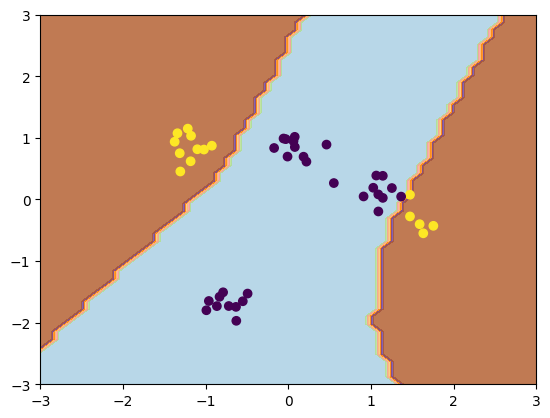

In [2]:
X, y = datasets.make_blobs([10, 5, 10, 5, 10, 5], random_state=42)
y %= 2
mean, std = X.mean(0), X.std(0)
X = (X - mean ) / std

X_test, y_test = datasets.make_blobs([10, 5, 10, 5, 10, 5], random_state=42)
y_test %= 2
X_test = (X_test - mean) / std

# clf = LogisticRegression(random_state=1)
clf = MLPClassifier(hidden_layer_sizes=(10,), random_state=1, learning_rate_init=.1)
clf.fit(X, y)

def plot_contours(clf, X, y=None):
    xx = np.linspace(-3, 3, 50)
    yy = np.linspace(-3, 3, 50)
    xx, yy = np.meshgrid(xx, yy)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    plt.contourf(xx, yy, Z.reshape(xx.shape), cmap=plt.cm.Paired, alpha=0.8)
    if y is None:
        scatter_kwargs = dict(c='lightgray', edgecolor='k')
    else: 
        scatter_kwargs = dict(c=y)
    plt.scatter(X[:, 0], X[:, 1], **scatter_kwargs)
  
plot_contours(clf, X_test, y_test)
plt.show()

## Brute Force

In [3]:
from tqdm.auto import tqdm
import itertools

num_samples = 3
all_indices = range(len(X))
combinations = list(itertools.combinations(all_indices, num_samples))

scores = []
for indices in tqdm(combinations):
  indices = list(indices) 
  X_train, y_train = X[indices], y[indices]

  clf = LogisticRegression()
  clf = MLPClassifier(hidden_layer_sizes=(10,), random_state=1, learning_rate_init=.1)
  if len(np.unique(y_train)) == 1:
    score = np.mean(y_train[0] == y_test)
    scores.append(score)
    continue
  clf.fit(X_train, y_train)
  score = clf.score(X_test, y_test)
  scores.append(score)


/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 19%|█▊        | 2630/14190 [00:07<00:18, 633.44it/s]/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 20%|██        | 2898/14190 [00:08<00:31, 360.83it/s]/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 21%|██        | 2968/14190 [00:08<00:39, 287.36it/s]/home/dhuseljic/miniconda3/envs/dal-toolbo

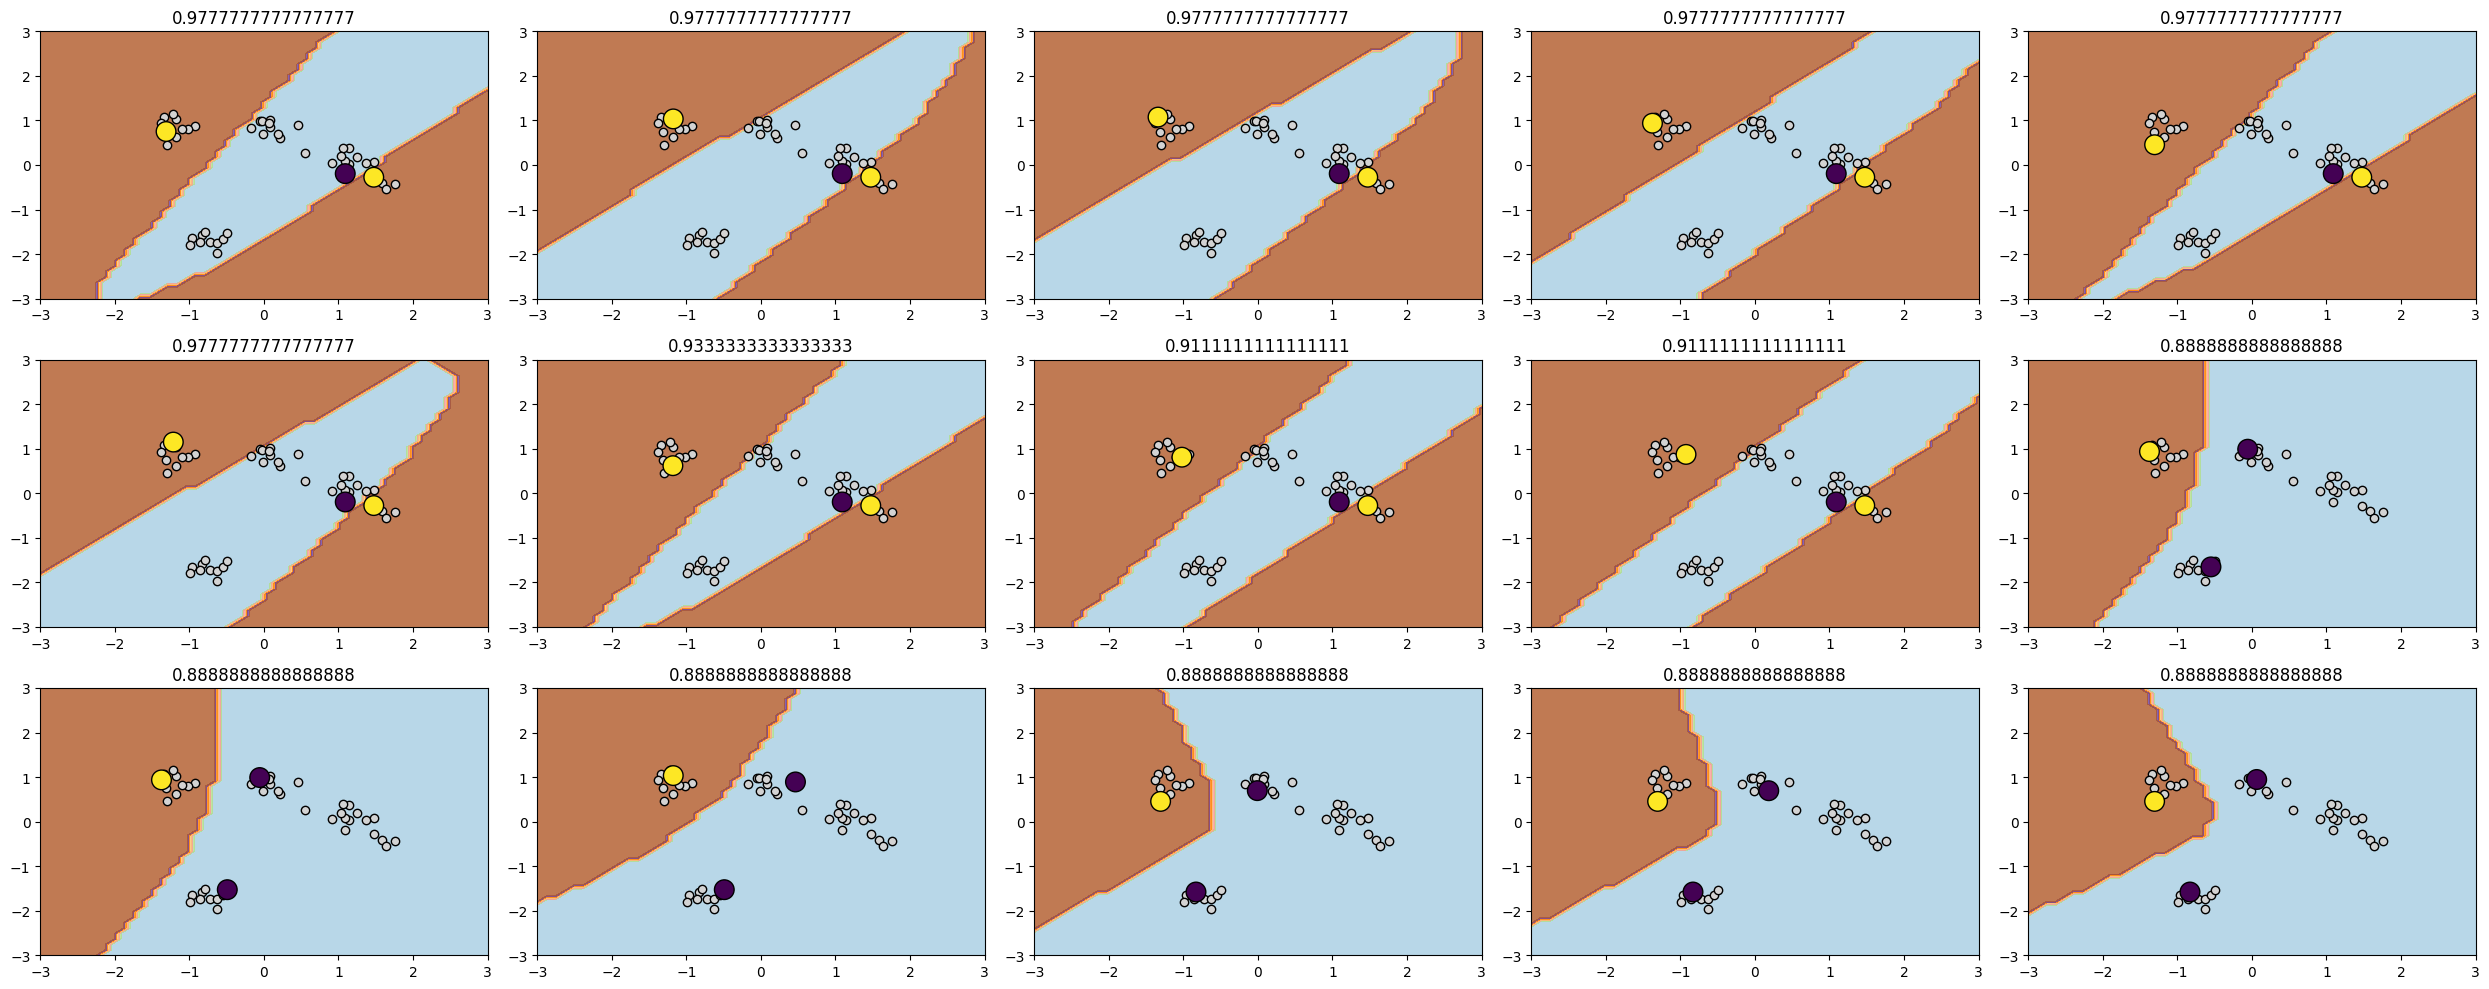

In [4]:
top_indices = np.argsort(scores)[::-1]

figure, axes = plt.subplots(3, 5, figsize=(25, 10))
axes = np.ravel(axes)

for idx, ax in zip(top_indices, axes):
    clf = MLPClassifier(hidden_layer_sizes=(10,), random_state=1, learning_rate_init=.1)
    indices = list(combinations[idx])
    X_train, y_train = X[indices], y[indices]
    clf.fit(X_train, y_train)
    plt.sca(ax)
    plot_contours(clf, X)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=200, edgecolors='k')
    plt.title(clf.score(X_test, y_test))
    

plt.tight_layout()
plt.show()

## Random Sampling

In [17]:
from tqdm.auto import tqdm
import itertools

num_samples = 4
num_combs = 2000
all_indices = range(len(X))
combinations = list(itertools.combinations(all_indices, num_samples))

rnd_idx = np.random.choice(range(len(combinations)), size=num_combs, replace=False)
sampled_combinations = np.array(combinations)[rnd_idx]

scores = []
for indices in tqdm(sampled_combinations):
  indices = list(indices) 
  X_train, y_train = X[indices], y[indices]

  clf = LogisticRegression()
  clf = MLPClassifier(hidden_layer_sizes=(10,), random_state=1, learning_rate_init=.1)
  if len(np.unique(y_train)) == 1:
    score = np.mean(y_train[0] == y_test)
    scores.append(score)
    continue
  clf.fit(X_train, y_train)
  score = clf.score(X_test, y_test)
  scores.append(score)


  0%|          | 0/2000 [00:00<?, ?it/s]

/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
  7%|▋         | 147/2000 [00:00<00:06, 283.39it/s]/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 18%|█▊        | 353/2000 [00:01<00:05, 286.56it/s]/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 19%|█▉        | 382/2000 [00:01<00:05, 280.47it/s]/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-p

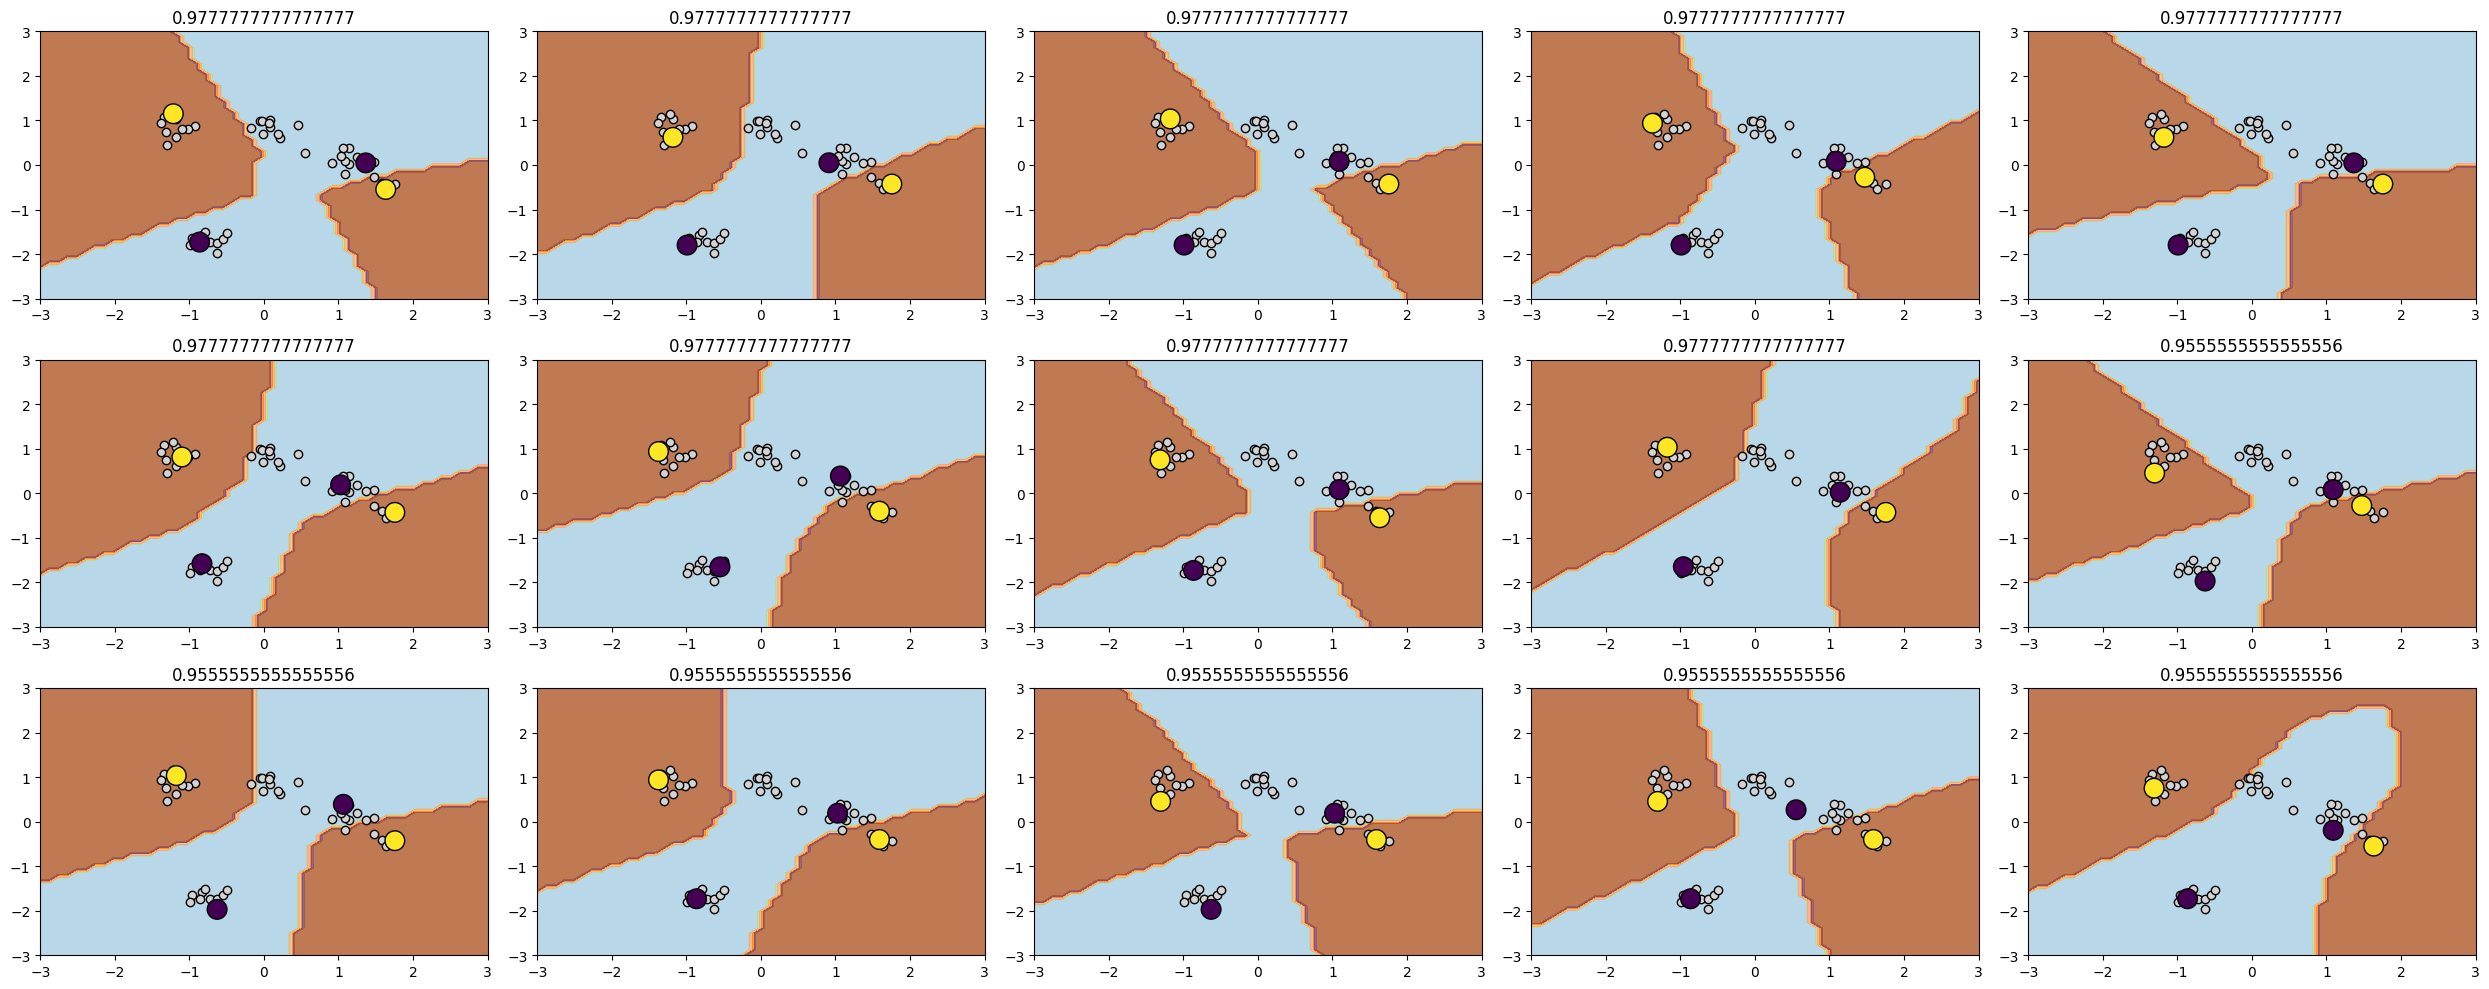

In [18]:
top_indices = np.argsort(scores)[::-1]

figure, axes = plt.subplots(3, 5, figsize=(25, 10))
axes = np.ravel(axes)

for idx, ax in zip(top_indices, axes):
    clf = MLPClassifier(hidden_layer_sizes=(10,), random_state=1, learning_rate_init=.1)
    indices = list(sampled_combinations[idx])
    X_train, y_train = X[indices], y[indices]
    clf.fit(X_train, y_train)
    plt.sca(ax)
    plot_contours(clf, X)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=200, edgecolors='k')
    plt.title(clf.score(X_test, y_test))
    

plt.tight_layout()
plt.show()

## Generating diverse batches

In [3]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import pairwise_distances

def batch_distance(X1, X2):
    cost_matrix = pairwise_distances(X1, X2)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    # matches = list(zip(row_ind, col_ind))
    # print(cost_matrix)
    # print(cost_matrix[row_ind, col_ind])
    return np.sum(cost_matrix[row_ind, col_ind])

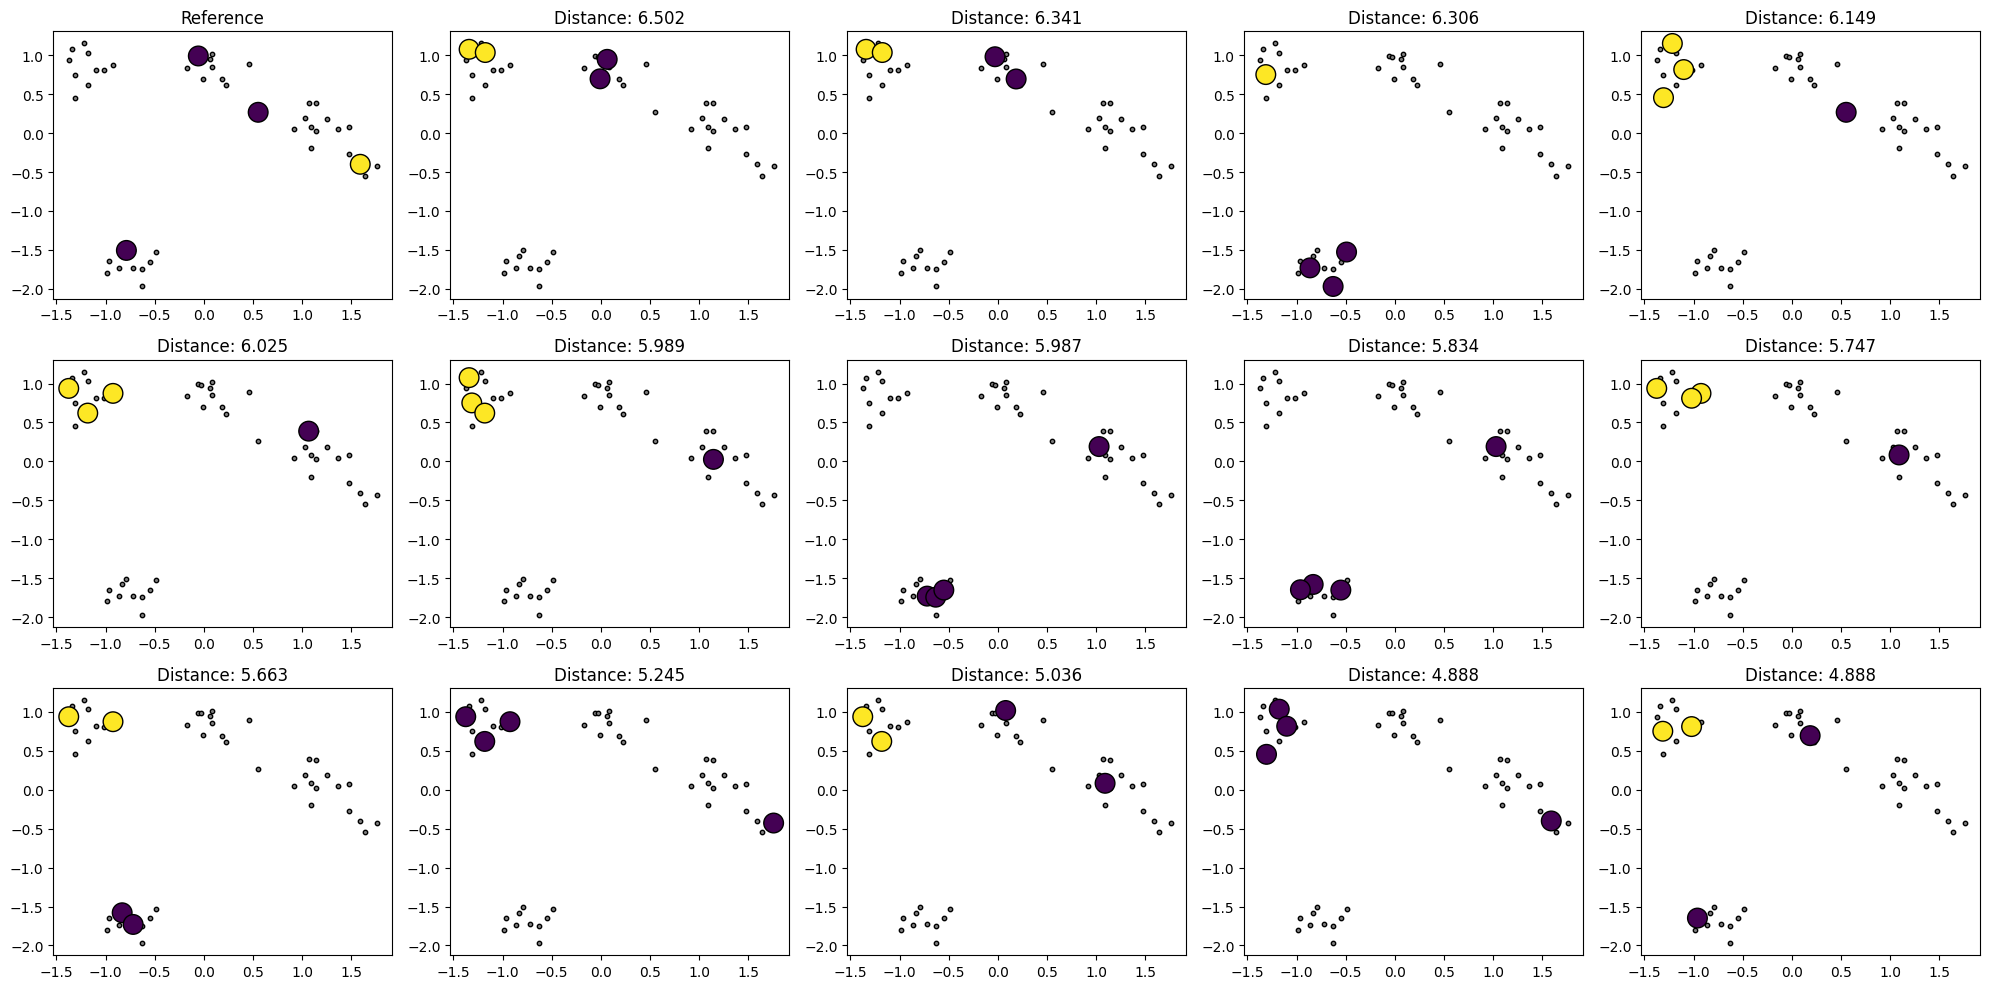

In [4]:
# Selecting new batches which are similar/unsimilar to the current batch
import itertools

np.random.seed(123)

num_samples = 4
all_indices = range(len(X))
combinations = list(itertools.combinations(all_indices, num_samples))

num_combinations = 100
combinations = np.array(combinations)
rnd_idx = np.random.permutation(len(combinations))
sampled_combinations  = combinations[rnd_idx][:num_combinations]


X_1, y_1 = X[sampled_combinations[0]],  y[sampled_combinations[0]]

distances = np.array([batch_distance(X_1, X[comb_indices]) for comb_indices in sampled_combinations])
sort_indices = np.argsort(-distances) # unsimilar

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = np.ravel(axes)
plt.sca(axes[0])
plt.title('Reference')
plt.scatter(X[:, 0], X[:, 1], c='gray', s=10, edgecolors='k')
plt.scatter(X_1[:, 0], X_1[:, 1], c=y_1, s=200, edgecolors='k')
axes = np.delete(axes, 0)

for ax, idx in zip(axes, sort_indices):
    comb_indices = sampled_combinations[idx]
    X_train, y_train = X[comb_indices], y[comb_indices]
    plt.sca(ax)
    plt.title("Distance: {:.3f}".format(distances[idx]))
    plt.scatter(X[:, 0], X[:, 1], c='gray', s=10, edgecolors='k')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=200, edgecolors='k')
plt.tight_layout()
plt.show()

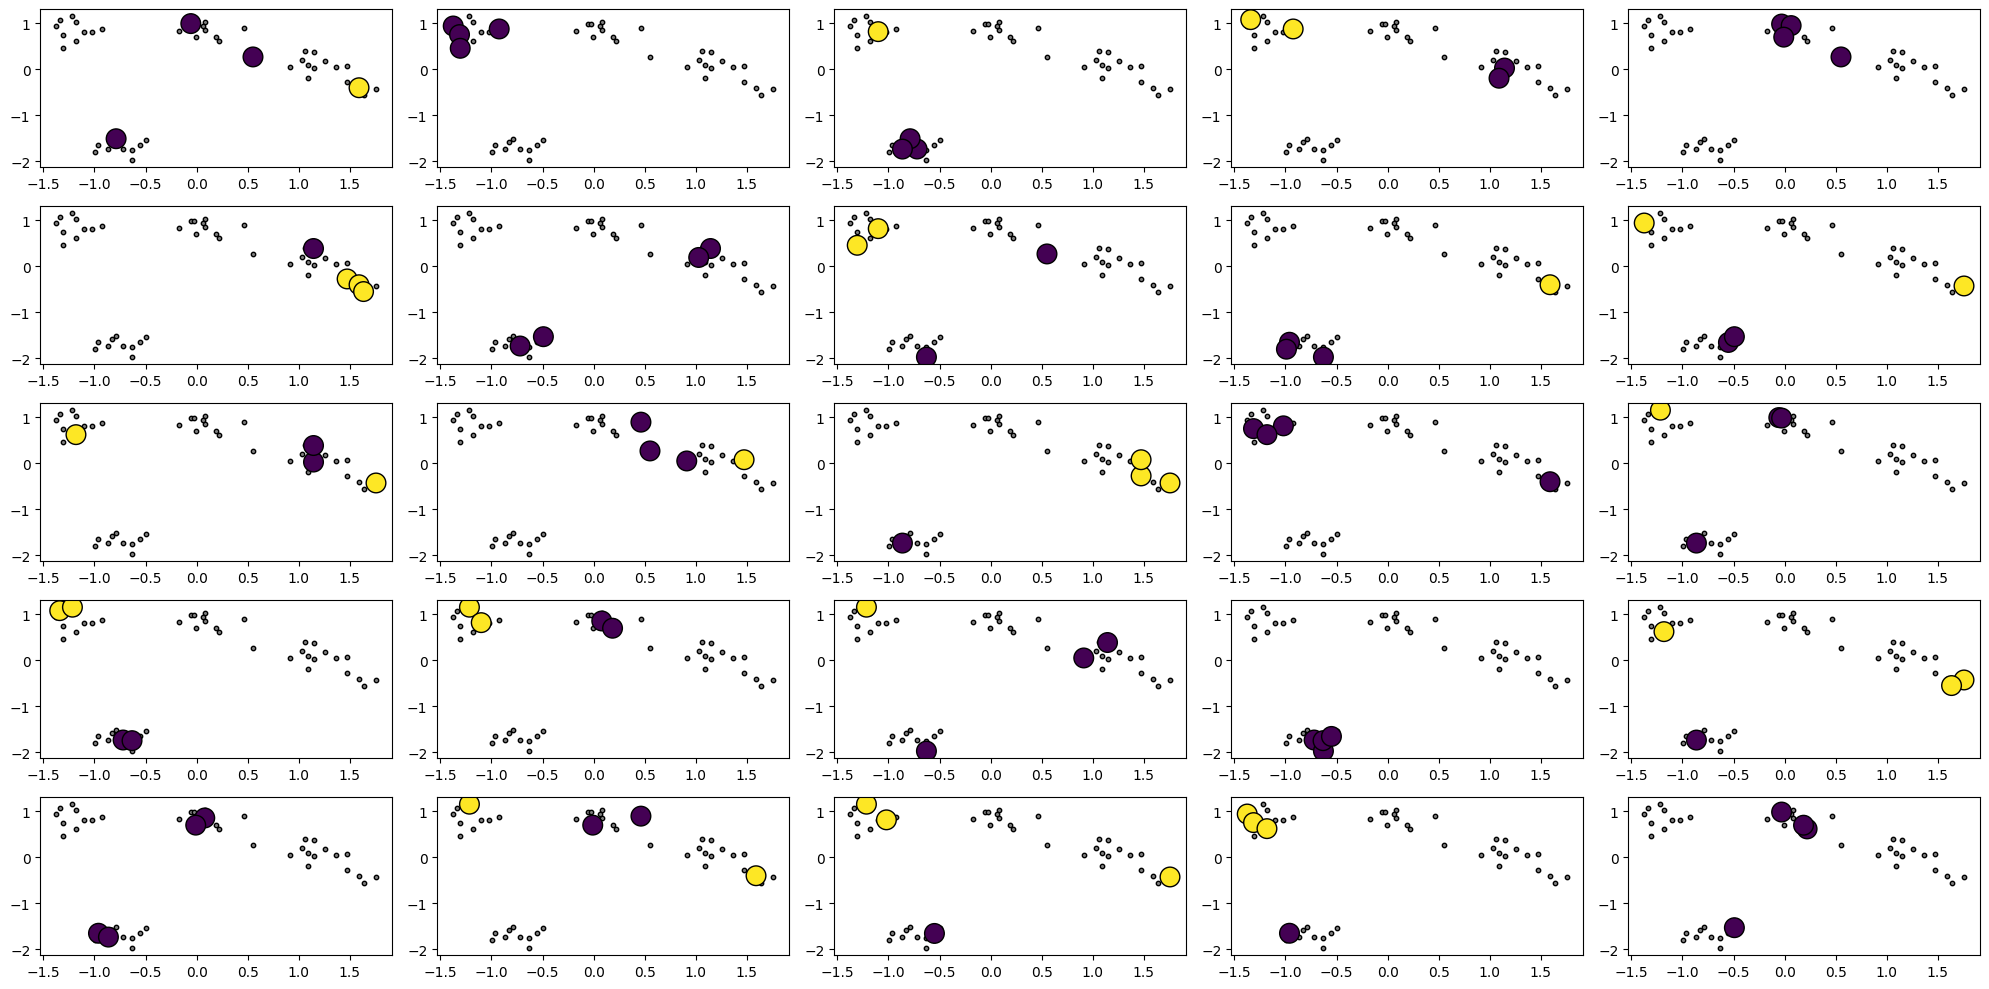

In [7]:
# Greedy selection of batches 
np.random.seed(123)

num_batches = 30
batch_indices = []

# Select a batch for reference

idx = np.random.permutation(len(combinations))[0]
batch_indices.append(idx)

for i_batch in range(1, num_batches):
    random_indices = np.random.permutation(len(combinations))[:100]
    distances = []
    for batch_idx in batch_indices:
        X_batch = X[combinations[batch_idx]]
        distances.append([batch_distance(X_batch, X[comb_indices]) for comb_indices in combinations[random_indices]])
    idx = np.argmax(np.min(distances, axis=0))
    idx = random_indices[idx]
    batch_indices.append(idx)


fig, axes = plt.subplots(5, 5, figsize=(20, 10))
axes = np.ravel(axes)

for ax, comb_indices in zip(axes, combinations[batch_indices]):
    X_train, y_train = X[comb_indices], y[comb_indices]
    plt.sca(ax)
    plt.scatter(X[:, 0], X[:, 1], c='gray', s=10, edgecolors='k')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=200, edgecolors='k')
plt.tight_layout()
plt.show()